=== Aggregated lap data ===
Weather  lap_number  lap_time  throttle_mean  brake_mean    rpm_mean
  Clear           1   111.822       0.845107    0.098032 7410.074753
  Clear           2   111.657       0.844229    0.098351 7408.760549
  Clear           3   111.723       0.843273    0.098148 7402.717572
  Clear           4   111.711       0.841865    0.097926 7403.245355
  Clear           5   111.606       0.841606    0.097906 7406.018493
  Clear           6   111.591       0.842803    0.097579 7404.677375
  Clear           7   111.624       0.841646    0.097789 7406.837559
  Clear           8   111.528       0.842958    0.097801 7408.204810
   Rain           1   113.793       0.838232    0.100901 7371.102796
   Rain           2   113.766       0.837741    0.101436 7369.526567
   Rain           3   113.748       0.836871    0.100372 7372.538982
   Rain           4   113.838       0.836695    0.100729 7368.545320
   Rain           5   113.835       0.836740    0.100304 7370.802309
   Rai

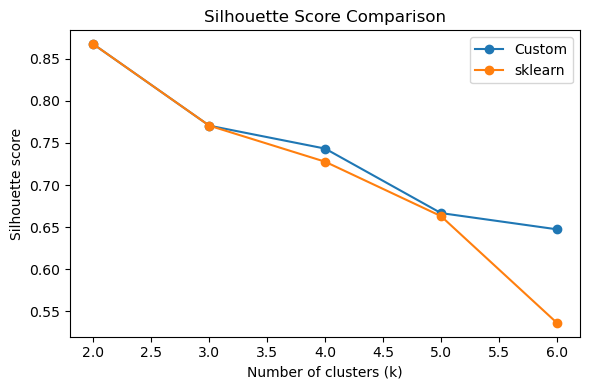

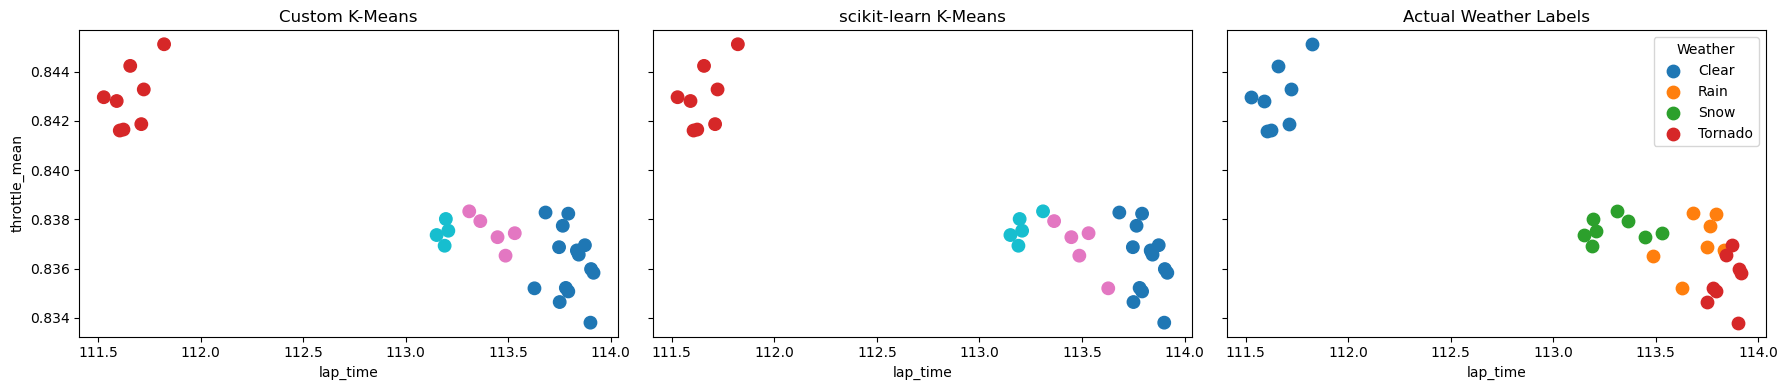

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import silhouette_score

# Load each weather CSV and tag the data with its weather label
weather_files = {
    'Clear':     'monzaCLEARbetter.csv',
    'Rain':      'monzaRAIN.csv',
    'Snow':      'monzaSNOW.csv',
    'Tornado':   'monzaTORNADO.csv',
}

dfs = []
for weather, path in weather_files.items():
    df = pd.read_csv(path, sep='\t')
    df['Weather'] = weather  # Add a column to track the weather condition
    dfs.append(df)

# Combine all weather data into a single DataFrame
data = pd.concat(dfs, ignore_index=True)

# Remove the first and last laps
data = data[data['lap_number'].between(1, 8)]

# Only keep valid laps (no invalid flags) and group by lap
# For each lap, compute max lap time and average throttle, brake, and rpm
valid = data[data['lap_time_invalid'] == 0]
laps = (
    valid
    .groupby(['Weather', 'lap_number'], as_index=False)
    .agg({
        'lap_time': 'max',
        'throttle': 'mean',
        'brake':    'mean',
        'rpm':      'mean'
    })
    .rename(columns={
        'throttle': 'throttle_mean',
        'brake':    'brake_mean',
        'rpm':      'rpm_mean'
    })
)

# Print the cleaned and aggregated data
print("=== Aggregated lap data ===")
print(laps.to_string(index=False))

# Choose which features to use in clustering
features    = ['lap_time','throttle_mean']
X           = laps[features].values
true_labels = laps['Weather'].values  # use this later for evaluation

# Custom K-Means class
class KMeansCustom:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4, random_state=None):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.tol          = tol
        self.random_state = random_state

    def fit(self, X):
        rng = np.random.default_rng(self.random_state)
        n, _ = X.shape

        # Initialize centroids randomly
        self.centroids = X[rng.choice(n, self.n_clusters, replace=False)]

        for _ in range(self.max_iter):
            # Calculate distances from points to centroids
            dists  = np.linalg.norm(X[:,None,:] - self.centroids[None,:,:], axis=2)
            labels = np.argmin(dists, axis=1)

            # Recalculate centroids based on cluster assignments
            new_centroids  = np.vstack([
                X[labels==k].mean(axis=0) if np.any(labels==k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # Check for convergence
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids

        self.labels_ = labels
        return self

    def predict(self, X):
        dists = np.linalg.norm(X[:,None,:] - self.centroids[None,:,:], axis=2)
        return np.argmin(dists, axis=1)

# Set number of clusters to 4 (we have 4 weather types)
n_clusters = 4

# Fit the custom K-Means model
km_cust  = KMeansCustom(n_clusters=n_clusters, random_state=42).fit(X)
labels_c = km_cust.labels_

# Fit scikit-learn's KMeans for comparison
km_sklearn = SklearnKMeans(n_clusters=n_clusters, random_state=42)
labels_s   = km_sklearn.fit_predict(X)

# Evaluate how well each model did by comparing to the real weather labels
print("\n=== Confusion Matrix for Custom K-Means ===")
conf_c = pd.crosstab(laps['Weather'], labels_c, rownames=['Weather'], colnames=['Custom Cluster'])
print(conf_c)
purity_c = conf_c.max(axis=0).sum() / len(laps)
print(f"Purity (Custom) = {purity_c:.2f}")

print("\n=== Confusion Matrix for scikit-learn K-Means ===")
conf_s = pd.crosstab(laps['Weather'], labels_s, rownames=['Weather'], colnames=['sklearn Cluster'])
print(conf_s)
purity_s = conf_s.max(axis=0).sum() / len(laps)
print(f"Purity (sklearn) = {purity_s:.2f}")

# Try different values of k to see which gives the best clustering (based on silhouette score)
results = []
for k in range(2, 7):
    kmc = KMeansCustom(n_clusters=k, random_state=42).fit(X)
    sc  = silhouette_score(X, kmc.labels_)
    
    kms = SklearnKMeans(n_clusters=k, random_state=42)
    ls  = kms.fit_predict(X)
    ss  = silhouette_score(X, ls)

    results.append({
        'k': k,
        'silhouette_custom': sc,
        'silhouette_sklearn': ss
    })

# Show silhouette scores for each value of k
df_scores = pd.DataFrame(results)
print("\n=== Silhouette Scores by Cluster Count (k) ===")
print(df_scores.to_string(index=False))

# Plot silhouette scores for both models
plt.figure(figsize=(6,4))
plt.plot(df_scores.k, df_scores.silhouette_custom, marker='o', label='Custom')
plt.plot(df_scores.k, df_scores.silhouette_sklearn, marker='o', label='sklearn')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Plot how the clusters look vs. the true weather labels
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
feat_x, feat_y = features

# Plot custom clustering result
ax1.scatter(X[:,0], X[:,1], c=labels_c, s=80, cmap='tab10')
ax1.set_title('Custom K-Means')
ax1.set_xlabel(feat_x)
ax1.set_ylabel(feat_y)

# Plot sklearn clustering result
ax2.scatter(X[:,0], X[:,1], c=labels_s, s=80, cmap='tab10')
ax2.set_title('scikit-learn K-Means')
ax2.set_xlabel(feat_x)

# Plot true weather labels using different colors
colors = plt.cm.tab10.colors
for i, weather in enumerate(laps['Weather'].unique()):
    mask = laps['Weather'] == weather
    ax3.scatter(X[mask,0], X[mask,1], c=[colors[i]], s=80, label=weather)
ax3.set_title('Actual Weather Labels')
ax3.set_xlabel(feat_x)
ax3.legend(title='Weather')

plt.tight_layout()
plt.show()


/Users/stevenchase/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_birch.py:725: ConvergenceWarning: Number of subclusters found (2) by BIRCH is less than (4). Decrease the threshold.
  warnings.warn(


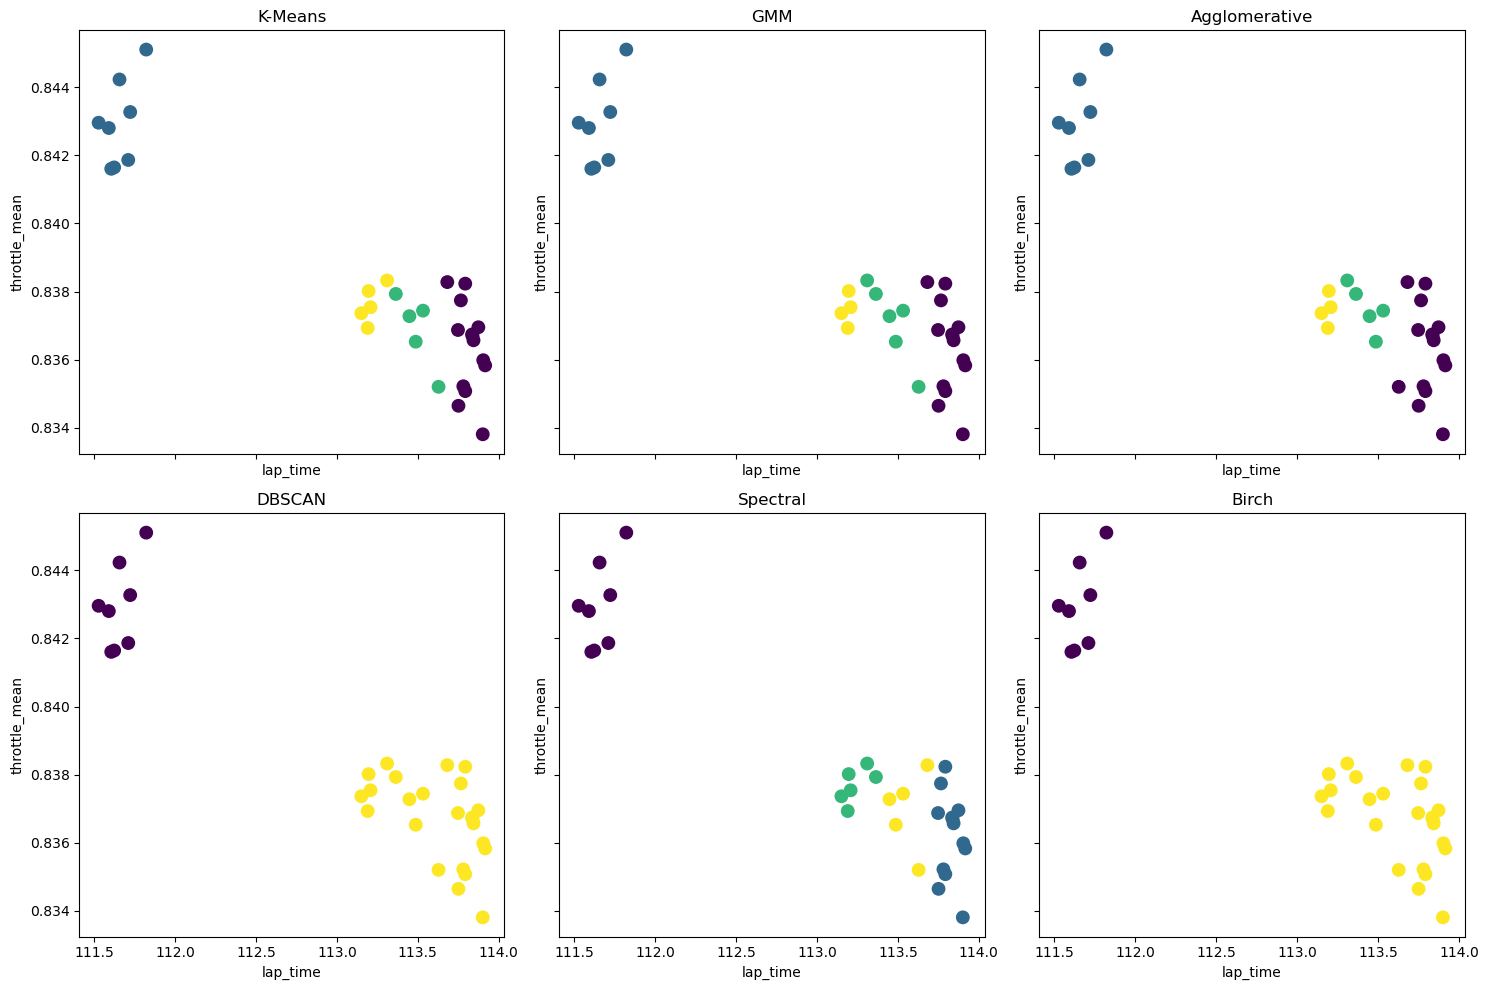

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    SpectralClustering,
    Birch
)
from sklearn.mixture import GaussianMixture

# Load & prepare the lap‐level DataFrame just as before:
weather_files = {
    'Clear':     'monzaCLEARbetter.csv',
    'Rain':      'monzaRAIN.csv',
    'Snow':      'monzaSNOW.csv',
    'Tornado': 'monzaTORNADO.csv',
}

# read all laps and drop invalid laps, then aggregate, same as before:
dfs = []
for w, path in weather_files.items():
    df = pd.read_csv(path, sep='\t')
    df['Weather'] = w
    dfs.append(df)
data = pd.concat(dfs, ignore_index=True)
data = data[data['lap_number'].between(1, 8)]

valid_data = data[data['lap_time_invalid'] == 0]
laps = (
    valid_data
      .groupby(['Weather','lap_number'], as_index=False)
      .agg({
          'lap_time': 'max',
          'throttle': 'mean',
          'brake':    'mean',
          'rpm':      'mean'
      })
      .rename(columns={
          'throttle':'throttle_mean',
          'brake':'brake_mean',
          'rpm':'rpm_mean'
      })
)


# Build the 2D feature matrix
X = laps[['lap_time','throttle_mean']].values

# Instantiate all the algorithms
algos = {
    'K-Means':       KMeans(n_clusters=4, random_state=42),
    'GMM':           GaussianMixture(n_components=4, random_state=42),
    'Agglomerative': AgglomerativeClustering(n_clusters=4),
    'DBSCAN':        DBSCAN(eps=0.3, min_samples=2),
    'Spectral':      SpectralClustering(n_clusters=4, random_state=42, assign_labels='kmeans'),
    'Birch':         Birch(n_clusters=4),
}

# Fit & get labels
labels = {}
for name, alg in algos.items():
    if hasattr(alg, 'fit_predict'):
        labels[name] = alg.fit_predict(X)
    else:
        alg.fit(X)
        labels[name] = alg.predict(X)

# Plot them in a 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, lab) in zip(axes, labels.items()):
    ax.scatter(X[:,0], X[:,1], c=lab, s=80)
    ax.set_title(name)
    ax.set_xlabel('lap_time')
    ax.set_ylabel('throttle_mean')

plt.tight_layout()
plt.show()
